=== 8:1:1 Data Split Verification ===
Train Set: 50054 samples (80.0%), Churn Rate: 15.80%
Test Set: 6257 samples (10.0%), Churn Rate: 15.81%
Validation Set: 6257 samples (10.0%), Churn Rate: 15.79%

=== Logistic Regression Preprocessing Completed ===
Features standardized (mean=0, std=1) using TRAIN data only (no leakage)

=== Starting GridSearchCV for Logistic Regression ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== Logistic Regression GridSearch Completed ===
Best Parameters: {'C': 100, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}
Best Cross-Validation AUC: 0.8693
Key Params: class_weight=balanced, max_iter=1000
Independent Validation Set AUC (Best Model): 0.8665

=== Logistic Regression Test Set Evaluation ===
Core Metric - Churn Recall: 0.8979 (covers 89.8% of real churners)
Discrimination - AUC: 0.8657 (≥0.85 = Good for linear models)
Efficiency - Churn Precision: 0.3474 (reduces false positive waste)
Balance - F1 Score: 0.501 (trad

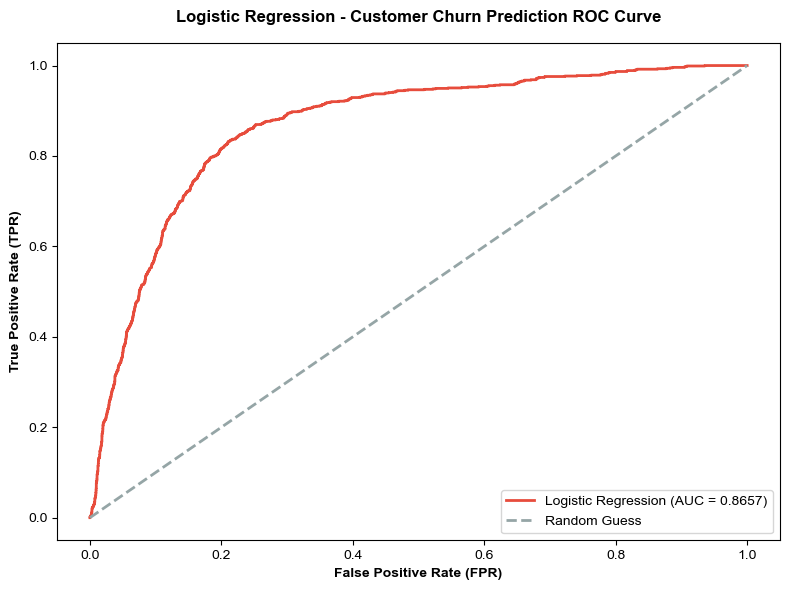

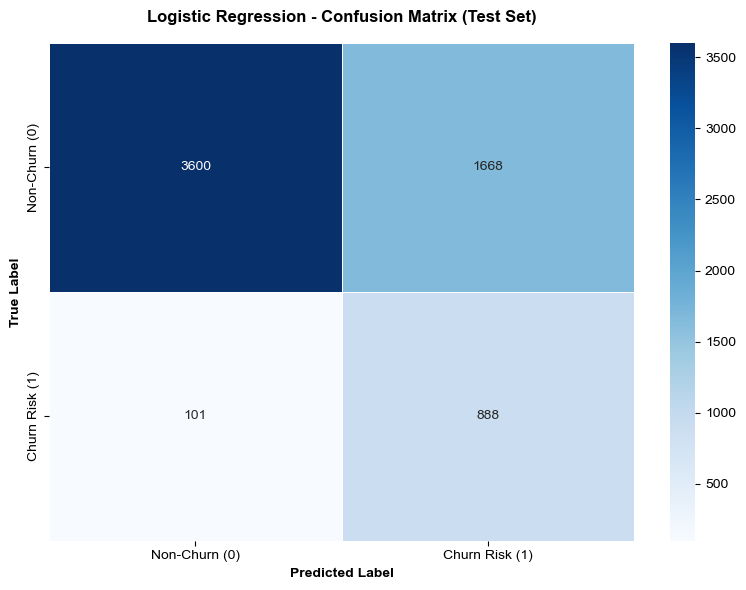


=== Confusion Matrix Interpretation ===
True Negatives (TN): 3600 - Correctly predicted non-churners
False Positives (FP): 1668 - Wrongly predicted churners (false alarms)
False Negatives (FN): 101 - Missed real churners (critical errors)
True Positives (TP): 888 - Correctly predicted churners


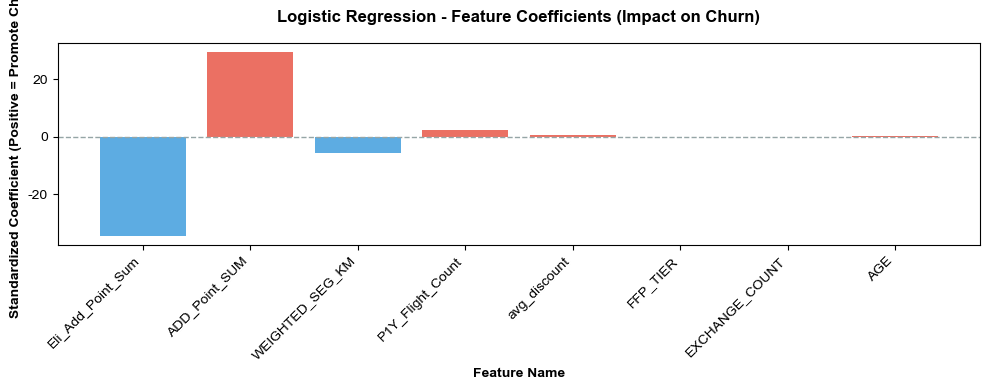


=== Feature Impact Interpretation ===
Features PROMOTING Churn (Positive Coef): ADD_Point_SUM, P1Y_Flight_Count, avg_discount, AGE
Features INHIBITING Churn (Negative Coef): Eli_Add_Point_Sum, WEIGHTED_SEG_KM, FFP_TIER, EXCHANGE_COUNT
Most Impactful Feature: Eli_Add_Point_Sum (Abs Coef: 34.5646)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, confusion_matrix
)
import seaborn as sns  # 新增：用于更美观的混淆矩阵可视化
import warnings

# -------------------------- 1. 基础配置（警告控制 + 英文图表） --------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10

# -------------------------- 2. 复用流失标签计算 --------------------------
def calculate_is_churn(df):
    """Calculate churn label (1 = Inactive now + Historical active)"""
    required_cols = ["L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # 1. 当前沉默状态（近1年无行为）
    inactive_now = (
            (df["L1Y_Flight_Count"] == 0) &
            (df["L1Y_Points_Sum"] == 0) &
            (df["L1Y_ELi_Add_Points"] == 0)
    )

    # 2. 历史活跃状态（上1年或代理字段有行为）
    active_conditions = []
    if "P1Y_Flight_Count" in df.columns:
        df["P1Y_Flight_Count"] = pd.to_numeric(df["P1Y_Flight_Count"], errors="coerce").fillna(0)
        active_conditions.append(df["P1Y_Flight_Count"] > 0)
    if "P1Y_Points_Sum" in df.columns:
        df["P1Y_Points_Sum"] = pd.to_numeric(df["P1Y_Points_Sum"], errors="coerce").fillna(0)
        active_conditions.append(df["P1Y_Points_Sum"] > 0)
    if not active_conditions:
        if {"FLIGHT_COUNT", "L1Y_Flight_Count"}.issubset(df.columns):
            df["FLIGHT_COUNT"] = pd.to_numeric(df["FLIGHT_COUNT"], errors="coerce").fillna(0)
            active_conditions.append((df["FLIGHT_COUNT"] - df["L1Y_Flight_Count"]) > 0)
        if {"Points_Sum", "L1Y_Points_Sum"}.issubset(df.columns):
            df["Points_Sum"] = pd.to_numeric(df["Points_Sum"], errors="coerce").fillna(0)
            active_conditions.append((df["Points_Sum"] - df["L1Y_Points_Sum"]) > 0)

    if not active_conditions:
        raise ValueError("Cannot determine historical active status: Missing P1Y/proxy columns")
    historical_active = np.logical_or.reduce(active_conditions)

    # 3. 最终流失标签
    df["is_churn"] = (inactive_now & historical_active).astype(int)
    return df

# -------------------------- 3. 8:1:1数据划分 --------------------------
def split_data_811(X, y, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

# -------------------------- 4. 逻辑回归专用预处理 --------------------------
def preprocess_logistic(X_train, X_test, X_val):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    feature_names = X_train.columns
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)

    print("\n=== Logistic Regression Preprocessing Completed ===")
    print(f"Features standardized (mean=0, std=1) using TRAIN data only (no leakage)")
    return X_train_scaled, X_test_scaled, X_val_scaled, scaler

# -------------------------- 5. 逻辑回归训练 --------------------------
def train_logistic_optimized(X_train_scaled, X_val_scaled, y_train, y_val, feature_list):
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced'],
        'max_iter': [1000]
    }

    log_model = LogisticRegression(
        random_state=42,
        verbose=0
    )

    grid_search = GridSearchCV(
        estimator=log_model,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    print("\n=== Starting GridSearchCV for Logistic Regression ===")
    grid_search.fit(X_train_scaled, y_train)

    best_logistic = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_val_auc = grid_search.best_score_

    print(f"\n=== Logistic Regression GridSearch Completed ===")
    print(f"Best Parameters: {best_params}")
    print(f"Best Cross-Validation AUC: {best_val_auc:.4f}")
    print(f"Key Params: class_weight=balanced, max_iter=1000")

    y_val_proba = best_logistic.predict_proba(X_val_scaled)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_proba)
    print(f"Independent Validation Set AUC (Best Model): {val_auc:.4f}")

    return best_logistic, best_params

# -------------------------- 6. 模型评估与可视化（新增混淆矩阵） --------------------------
def evaluate_logistic(best_logistic, X_test_scaled, y_test, feature_list, scaler):
    # 测试集预测
    y_test_proba = best_logistic.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = best_logistic.predict(X_test_scaled)

    # 计算核心业务指标
    metrics = {
        "Model": "Logistic Regression (8:1:1 Split + GridSearchCV)",
        "AUC": round(roc_auc_score(y_test, y_test_proba), 4),
        "Churn Recall": round(recall_score(y_test, y_test_pred, zero_division=0), 4),
        "Churn Precision": round(precision_score(y_test, y_test_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test, y_test_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_test_pred), 4)
    }

    # 打印评估结果
    print("\n=== Logistic Regression Test Set Evaluation ===")
    print(f"Core Metric - Churn Recall: {metrics['Churn Recall']} (covers {metrics['Churn Recall'] * 100:.1f}% of real churners)")
    print(f"Discrimination - AUC: {metrics['AUC']} (≥0.85 = Good for linear models)")
    print(f"Efficiency - Churn Precision: {metrics['Churn Precision']} (reduces false positive waste)")
    print(f"Balance - F1 Score: {metrics['F1 Score']} (trade-off between recall and precision)")

    # 详细分类报告
    print("\n=== Detailed Classification Report ===")
    print(classification_report(
        y_test, y_test_pred,
        target_names=["Non-Churn (0)", "Churn Risk (1)"],
        digits=4
    ))

    # 1. 可视化ROC曲线
    plt.figure()
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, color="#e74c3c", linewidth=2, label=f"Logistic Regression (AUC = {metrics['AUC']})")
    plt.plot([0, 1], [0, 1], color="#95a5a6", linewidth=2, linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate (FPR)", fontweight="bold")
    plt.ylabel("True Positive Rate (TPR)", fontweight="bold")
    plt.title("Logistic Regression - Customer Churn Prediction ROC Curve", fontweight="bold", pad=15)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # 2. 新增：混淆矩阵可视化
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    # 用seaborn绘制热力图，标注数值
    sns.heatmap(cm,
                annot=True,  # 显示数值
                fmt="d",  # 数值格式为整数
                cmap="Blues",  # 配色
                xticklabels=["Non-Churn (0)", "Churn Risk (1)"],
                yticklabels=["Non-Churn (0)", "Churn Risk (1)"],
                cbar=True,
                linewidths=0.5)
    plt.xlabel("Predicted Label", fontweight="bold")
    plt.ylabel("True Label", fontweight="bold")
    plt.title("Logistic Regression - Confusion Matrix (Test Set)", fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

    # 打印混淆矩阵解读
    tn, fp, fn, tp = cm.ravel()
    print("\n=== Confusion Matrix Interpretation ===")
    print(f"True Negatives (TN): {tn} - Correctly predicted non-churners")
    print(f"False Positives (FP): {fp} - Wrongly predicted churners (false alarms)")
    print(f"False Negatives (FN): {fn} - Missed real churners (critical errors)")
    print(f"True Positives (TP): {tp} - Correctly predicted churners")

    # 3. 特征系数热力图
    plt.figure(figsize=(10, 4))
    coefs = best_logistic.coef_[0]
    coef_df = pd.DataFrame({
        "Feature": feature_list,
        "Coefficient": coefs,
        "Abs_Coefficient": np.abs(coefs)
    }).sort_values("Abs_Coefficient", ascending=False)

    colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]]
    plt.bar(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.8)
    plt.axhline(y=0, color="#95a5a6", linestyle="--", linewidth=1)
    plt.xlabel("Feature Name", fontweight="bold")
    plt.ylabel("Standardized Coefficient (Positive = Promote Churn)", fontweight="bold")
    plt.title("Logistic Regression - Feature Coefficients (Impact on Churn)", fontweight="bold", pad=15)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 特征系数解读
    print("\n=== Feature Impact Interpretation ===")
    positive_features = coef_df[coef_df["Coefficient"] > 0]["Feature"].tolist()
    negative_features = coef_df[coef_df["Coefficient"] < 0]["Feature"].tolist()
    print(f"Features PROMOTING Churn (Positive Coef): {', '.join(positive_features)}")
    print(f"Features INHIBITING Churn (Negative Coef): {', '.join(negative_features)}")
    print(f"Most Impactful Feature: {coef_df.iloc[0]['Feature']} (Abs Coef: {coef_df.iloc[0]['Abs_Coefficient']:.4f})")

    return metrics, coef_df

# -------------------------- 7. 主流程执行 --------------------------
if __name__ == "__main__":
    # 注意：这里需要替换为你的数据路径，或衔接之前的数据预处理代码
    # df = pd.read_csv("//Users/mac123/Downloads/air_data.csv")  # 你的原始数据路径

    # 计算流失标签
    df = calculate_is_churn(df)

    # 筛选特征与标签
    feature_list = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    X = df[feature_list].dropna()
    y = df.loc[X.index, "is_churn"]

    # 8:1:1数据划分
    X_train, X_test, X_val, y_train, y_test, y_val = split_data_811(X, y)
    print("=== 8:1:1 Data Split Verification ===")
    print(f"Train Set: {len(X_train)} samples ({len(X_train) / len(X) * 100:.1f}%), Churn Rate: {y_train.mean():.2%}")
    print(f"Test Set: {len(X_test)} samples ({len(X_test) / len(X) * 100:.1f}%), Churn Rate: {y_test.mean():.2%}")
    print(f"Validation Set: {len(X_val)} samples ({len(X_val) / len(X) * 100:.1f}%), Churn Rate: {y_val.mean():.2%}")

    # 预处理
    X_train_scaled, X_test_scaled, X_val_scaled, scaler = preprocess_logistic(X_train, X_test, X_val)

    # 训练模型
    best_log_model, best_params = train_logistic_optimized(X_train_scaled, X_val_scaled, y_train, y_val, feature_list)

    # 评估与可视化（含混淆矩阵）
    log_metrics, log_coef_df = evaluate_logistic(best_log_model, X_test_scaled, y_test, feature_list, scaler)